In [93]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [94]:
df = pd.read_excel("flight_price.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


In [96]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [97]:
## Feature Engineering Process

df['Date'] = df['Date_of_Journey'].str.split("/").str[0] # Getting the date
df['Month'] = df['Date_of_Journey'].str.split("/").str[1] # Getting the month
df['Year'] = df['Date_of_Journey'].str.split("/").str[2] # getting the year

In [98]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  str   
 1   Date_of_Journey  10683 non-null  str   
 2   Source           10683 non-null  str   
 3   Destination      10683 non-null  str   
 4   Route            10682 non-null  str   
 5   Dep_Time         10683 non-null  str   
 6   Arrival_Time     10683 non-null  str   
 7   Duration         10683 non-null  str   
 8   Total_Stops      10682 non-null  str   
 9   Additional_Info  10683 non-null  str   
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  object
 12  Month            10683 non-null  object
 13  Year             10683 non-null  object
dtypes: int64(1), object(3), str(10)
memory usage: 2.0+ MB


In [100]:
df['Date'] = df['Date'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Year'] = df['Year'].astype(int)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
 11  Date             10683 non-null  int64
 12  Month            10683 non-null  int64
 13  Year             10683 non-null  int64
dtypes: int64(4), str(10)
memory usage: 2.0 MB


In [102]:
df.drop("Date_of_Journey",axis=1,inplace=True)

In [103]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [104]:
df['Arrival_Time']=df['Arrival_Time'].apply(lambda x: x.split(' ')[0])

In [105]:
df['Arrival_hour'] = df['Arrival_Time'].str.split(':').str[0]
df['Arrival_minute'] = df['Arrival_Time'].str.split(':').str[1]

In [106]:
df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,24,3,2019,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15


In [107]:
df['Arrival_hour'] = df['Arrival_hour'].astype(int)
df['Arrival_minute'] = df['Arrival_minute'].astype(int)


In [108]:
df.drop('Arrival_Time',axis=1,inplace=True)

In [109]:
df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,5,2019,13,15


In [110]:
df['Dep_hour'] = df['Dep_Time'].str.split(':').str[0]
df['Dep_minute'] = df['Dep_Time'].str.split(':').str[1]

In [111]:
df['Dep_hour'] = df['Dep_hour'].astype(int)
df['Dep_minute'] = df['Dep_minute'].astype(int)

In [112]:
df.drop('Dep_Time',axis=1,inplace=True)

In [113]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50


In [114]:
df['Total_Stops'].unique()

<ArrowStringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [115]:
df['Total_Stops'].isnull().sum()

np.int64(1)

In [116]:
df['Total_Stops'] = df['Total_Stops'].map({'non-stop':0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4,np.nan:1})

In [117]:
df[df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute


In [118]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,5,2019,13,15,5,50


In [119]:
df.drop('Route',axis=1,inplace=True)

In [120]:
df.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662,1,5,2019,13,15,5,50


In [121]:
df['Duration_hour']= df['Duration'].str.split(' ').str[0].str.split('h').str[0]
df['Duration_minute']=df['Duration'].str.split(' ').str[1].str.split('m').str[0]

In [122]:
df['Duration_hour'].isnull().sum()


np.int64(0)

In [123]:
df['Duration_minute'].isnull().sum()

np.int64(1032)

In [124]:
df[df['Duration_minute'].isnull()]

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_hour,Duration_minute
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882,9,6,2019,4,25,9,25,19,NaN
18,Air India,Delhi,Cochin,23h,2,No info,13381,12,6,2019,19,15,20,15,23,NaN
33,Jet Airways,Delhi,Cochin,22h,2,In-flight meal not included,10919,15,6,2019,12,35,14,35,22,NaN
44,Multiple carriers,Delhi,Cochin,12h,1,No info,13062,21,3,2019,21,0,9,0,12,NaN
53,IndiGo,Banglore,Delhi,3h,0,No info,3943,18,6,2019,0,15,21,15,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10591,Jet Airways,Delhi,Cochin,23h,2,No info,14300,12,6,2019,19,0,20,0,23,NaN
10638,Jet Airways,Banglore,New Delhi,14h,1,In-flight meal not included,7832,21,3,2019,11,25,21,25,14,NaN
10639,Air India,Delhi,Cochin,38h,3,No info,10493,3,6,2019,19,15,5,15,38,NaN
10673,Jet Airways,Delhi,Cochin,15h,2,No info,16704,27,5,2019,4,25,13,25,15,NaN


In [125]:
df['Duration_minute'] = df['Duration_minute'].fillna(0).astype(int)

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  str   
 1   Source           10683 non-null  str   
 2   Destination      10683 non-null  str   
 3   Duration         10683 non-null  str   
 4   Total_Stops      10683 non-null  int64 
 5   Additional_Info  10683 non-null  str   
 6   Price            10683 non-null  int64 
 7   Date             10683 non-null  int64 
 8   Month            10683 non-null  int64 
 9   Year             10683 non-null  int64 
 10  Arrival_hour     10683 non-null  int64 
 11  Arrival_minute   10683 non-null  int64 
 12  Dep_hour         10683 non-null  int64 
 13  Dep_minute       10683 non-null  int64 
 14  Duration_hour    10683 non-null  object
 15  Duration_minute  10683 non-null  int64 
dtypes: int64(10), object(1), str(5)
memory usage: 1.7+ MB


In [127]:
df['Duration_hour'] = df['Duration'].str.extract(r'(\d+)h', expand=False).fillna(0).astype(int)

In [128]:
df.drop('Duration',axis=1,inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Source           10683 non-null  str  
 2   Destination      10683 non-null  str  
 3   Total_Stops      10683 non-null  int64
 4   Additional_Info  10683 non-null  str  
 5   Price            10683 non-null  int64
 6   Date             10683 non-null  int64
 7   Month            10683 non-null  int64
 8   Year             10683 non-null  int64
 9   Arrival_hour     10683 non-null  int64
 10  Arrival_minute   10683 non-null  int64
 11  Dep_hour         10683 non-null  int64
 12  Dep_minute       10683 non-null  int64
 13  Duration_hour    10683 non-null  int64
 14  Duration_minute  10683 non-null  int64
dtypes: int64(11), str(4)
memory usage: 1.6 MB


In [129]:
df.drop('Additional_Info',axis=1,inplace=True)

In [130]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [131]:
df['Airline_encoded'] = encoder.fit_transform(df['Airline']) # type: ignore

In [132]:
df[['Airline','Airline_encoded']]

,Airline,Airline_encoded
0,IndiGo,3
1,Air India,1
2,Jet Airways,4
3,IndiGo,3
4,IndiGo,3
...,...,...
10678,Air Asia,0
10679,Air India,1
10680,Jet Airways,4
10681,Vistara,10


In [133]:
df['Source'].unique()

<ArrowStringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [134]:
df['Source_encoded'] = encoder.fit_transform(df['Source']) # type: ignore

In [135]:
df[['Source','Source_encoded']]

,Source,Source_encoded
0,Banglore,0
1,Kolkata,3
2,Delhi,2
3,Kolkata,3
4,Banglore,0
...,...,...
10678,Kolkata,3
10679,Kolkata,3
10680,Banglore,0
10681,Banglore,0


In [136]:
df['Destination'].unique()

<ArrowStringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [137]:
df['Destination_encoded'] = encoder.fit_transform(df['Destination']) # type: ignore
df[['Destination','Destination_encoded']]

,Destination,Destination_encoded
0,New Delhi,5
1,Banglore,0
2,Cochin,1
3,Banglore,0
4,New Delhi,5
...,...,...
10678,Banglore,0
10679,Banglore,0
10680,Delhi,2
10681,New Delhi,5


In [138]:
df.head(2)

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_hour,Duration_minute,Airline_encoded,Source_encoded,Destination_encoded
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,1,10,22,20,2,50,3,0,5
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,13,15,5,50,7,25,1,3,0


One hot encoding.

In [139]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[["Airline", "Source", "Destination"]])

In [140]:
ohe_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["Airline", "Source", "Destination"]),
    index=df.index,
)

In [ ]:
df = pd.concat([df, ohe_df], axis=1) #axis =0 by default. and axis = 1 concats by row

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 40 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Airline                                    10683 non-null  str    
 1   Source                                     10683 non-null  str    
 2   Destination                                10683 non-null  str    
 3   Total_Stops                                10683 non-null  int64  
 4   Price                                      10683 non-null  int64  
 5   Date                                       10683 non-null  int64  
 6   Month                                      10683 non-null  int64  
 7   Year                                       10683 non-null  int64  
 8   Arrival_hour                               10683 non-null  int64  
 9   Arrival_minute                             10683 non-null  int64  
 10  Dep_hour                         

In [143]:
df.drop('Airline',axis=1,inplace=True)
df.drop('Source',axis=1,inplace=True)
df.drop('Destination',axis=1,inplace=True)

In [144]:
df.head(1)

,Total_Stops,Price,Date,Month,Year,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Duration_hour,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,1,10,22,20,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [145]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Identify target column
if "Price" in df.columns:
    target_col = "Price"
elif "price" in df.columns:
    target_col = "price"
else:
    target_col = None

# Add a total duration in minutes if possible
if {"Duration_hour", "Duration_minute"}.issubset(df.columns):
    df["Duration_total_min"] = df["Duration_hour"] * 60 + df["Duration_minute"]

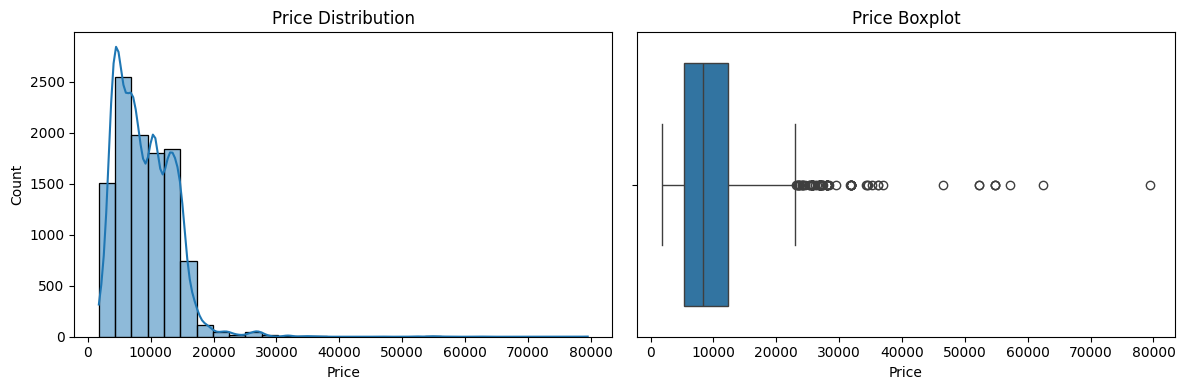

In [146]:
if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[target_col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title("Price Distribution")
    sns.boxplot(x=df[target_col], ax=axes[1])
    axes[1].set_title("Price Boxplot")
    plt.tight_layout()
    plt.show()

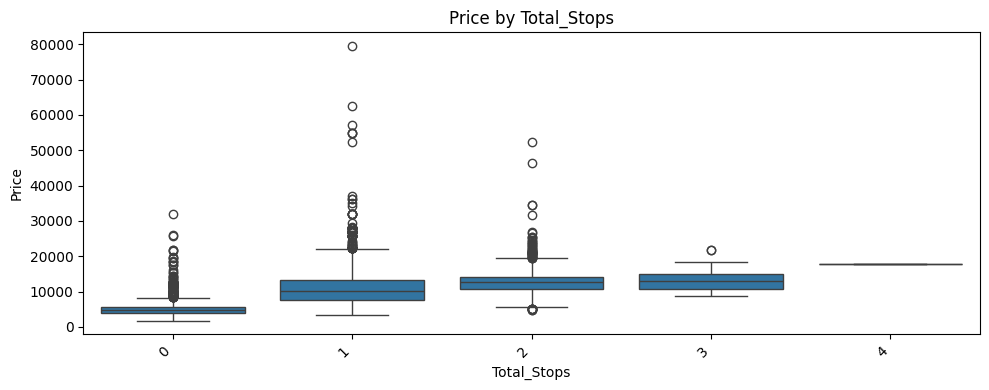

In [147]:
if target_col:
    cat_cols = [
        "Airline",
        "Source",
        "Destination",
        "Total_Stops",
        "Class",
        "Additional_Info",
    ]
    cat_cols = [c for c in cat_cols if c in df.columns]

    for col in cat_cols:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df, x=col, y=target_col)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"{target_col} by {col}")
        plt.tight_layout()
        plt.show()

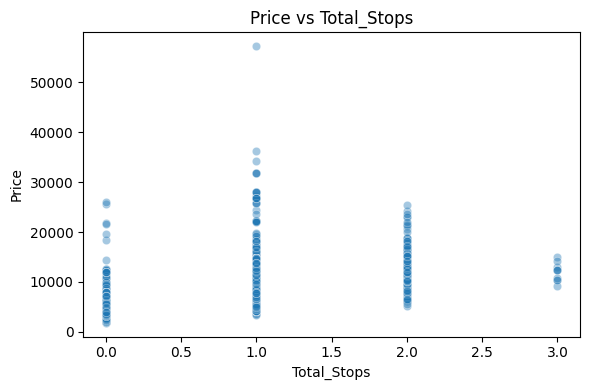

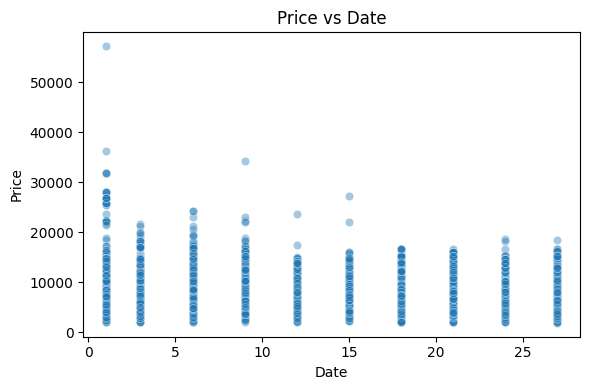

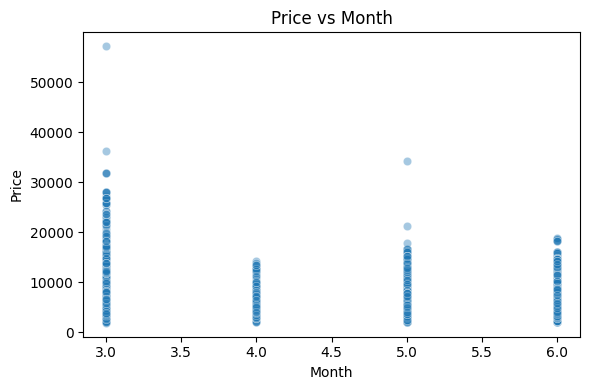

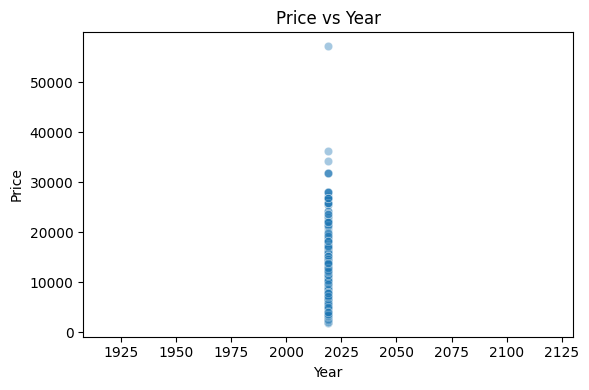

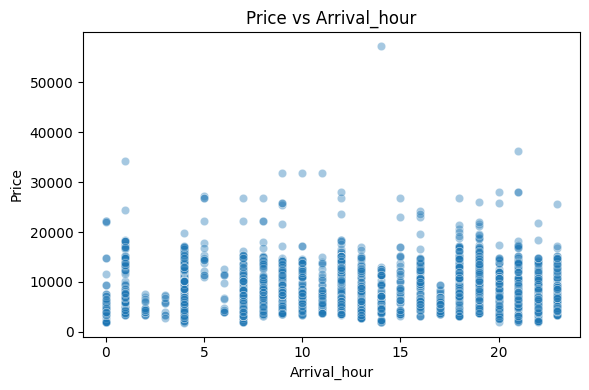

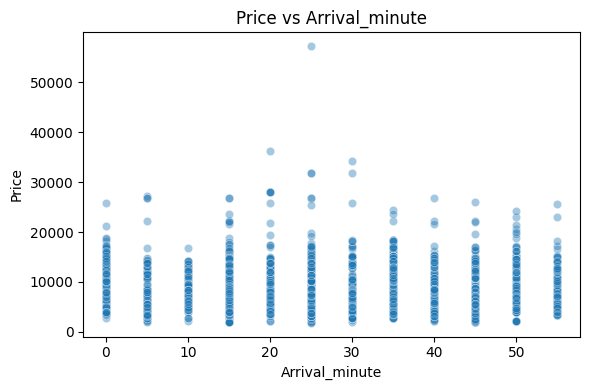

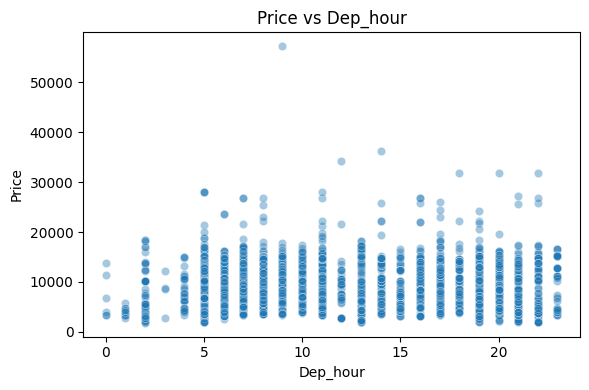

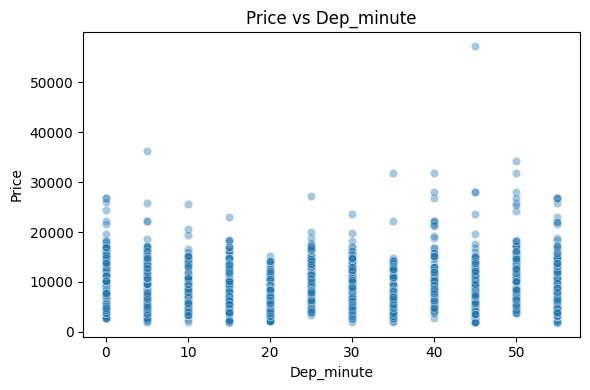

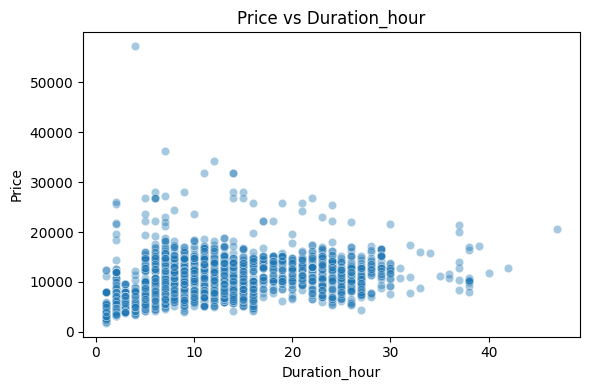

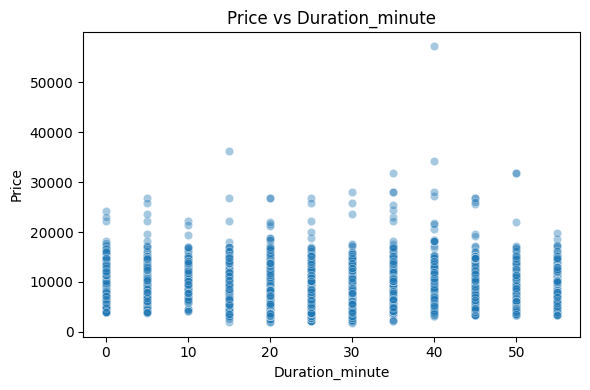

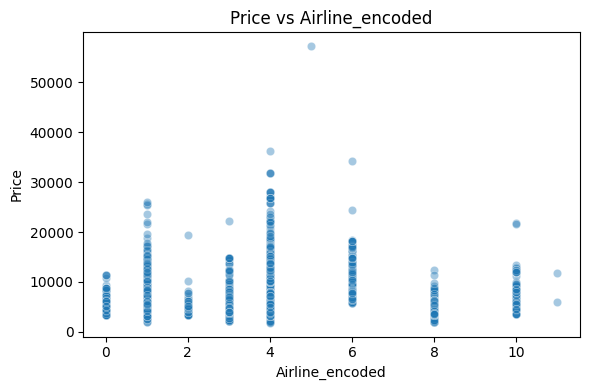

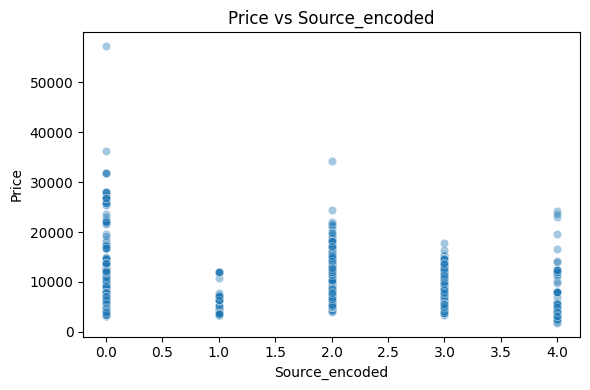

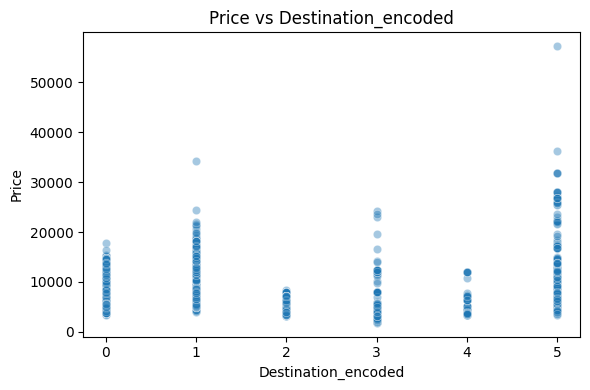

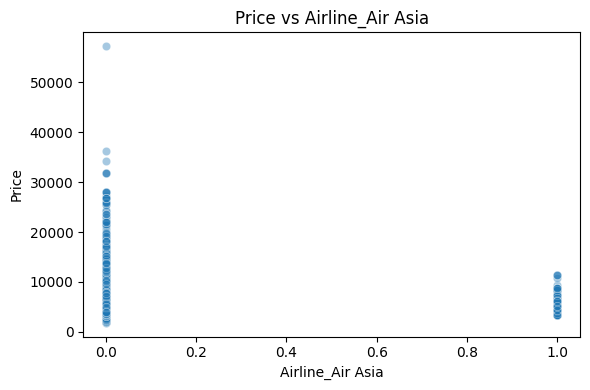

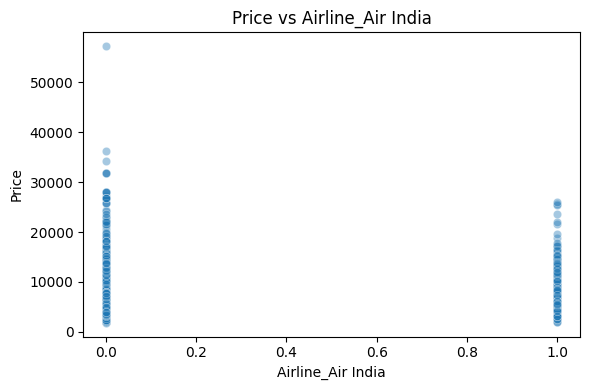

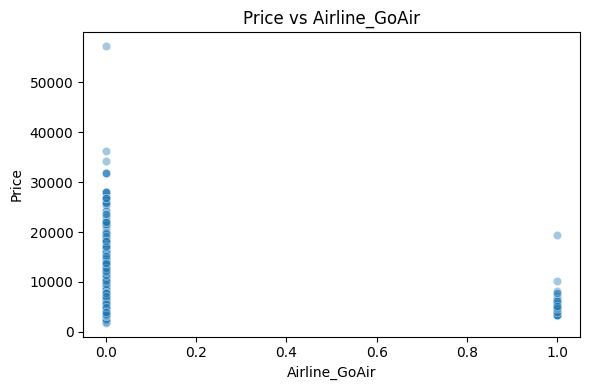

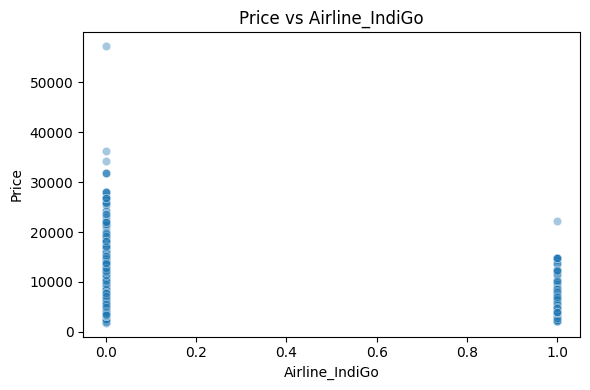

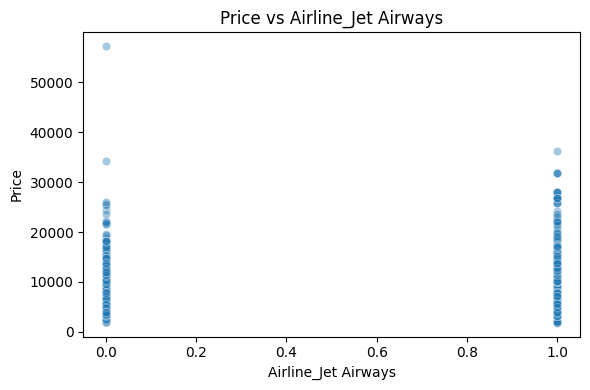

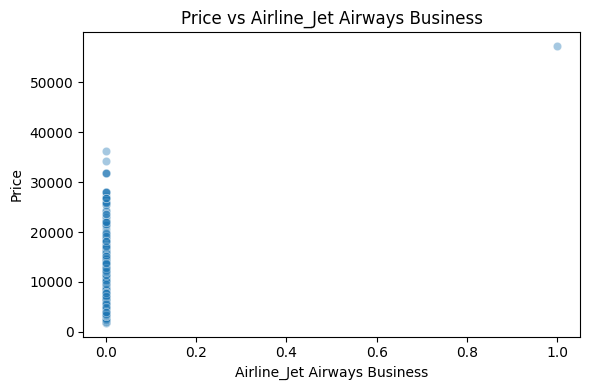

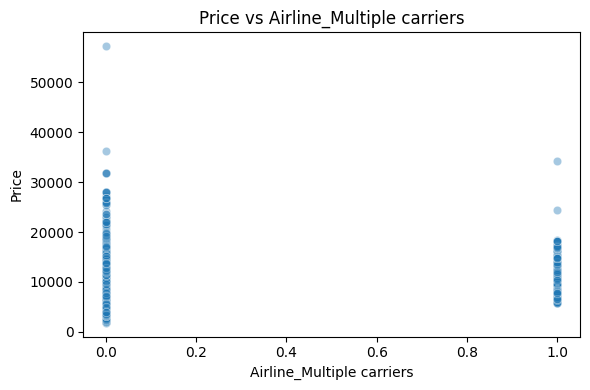

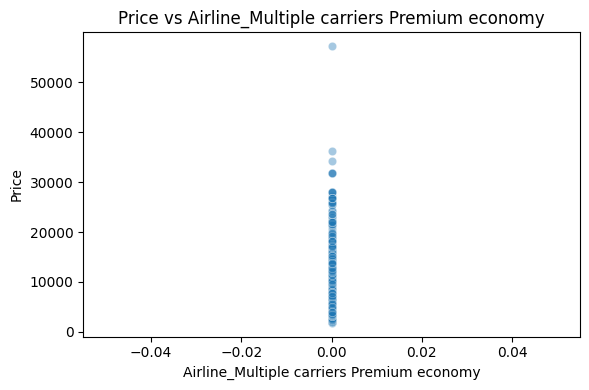

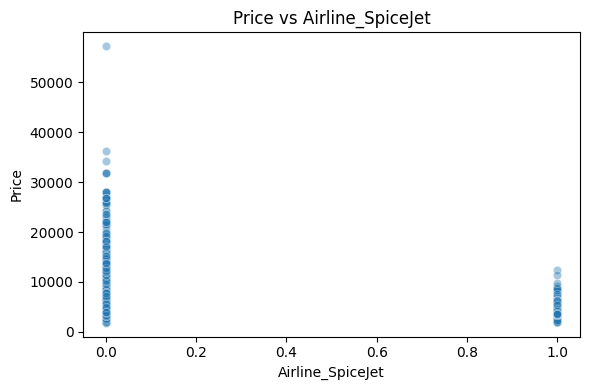

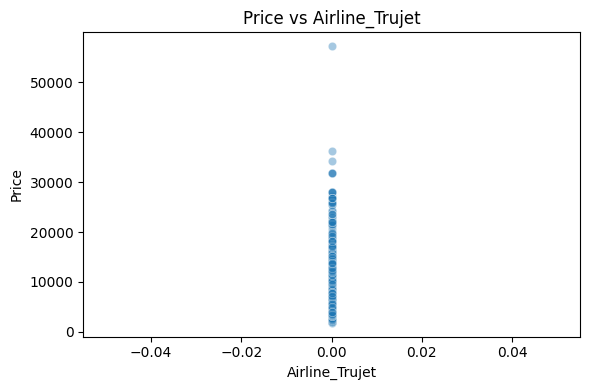

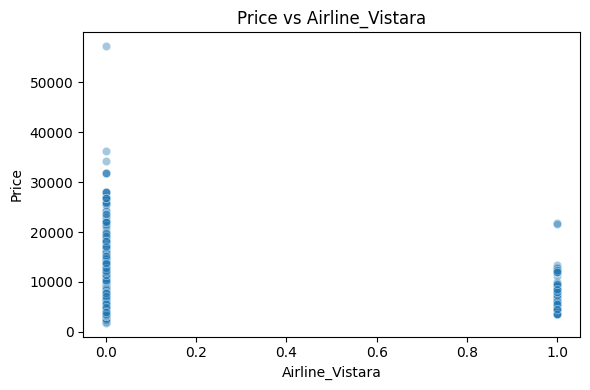

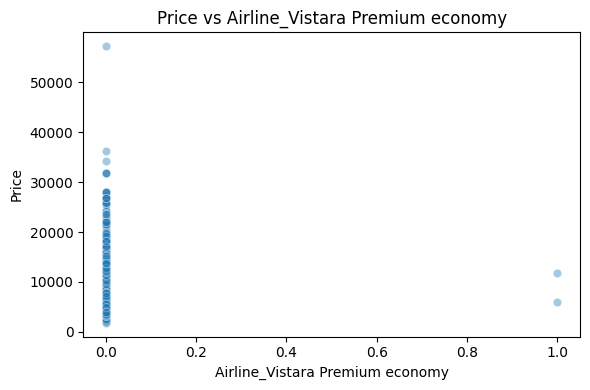

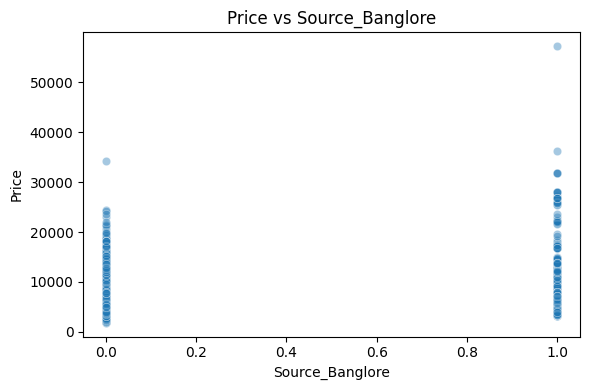

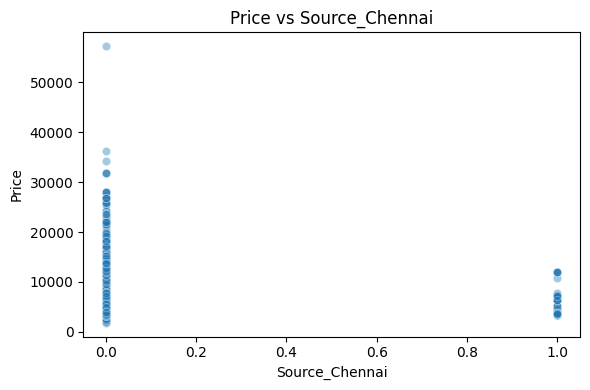

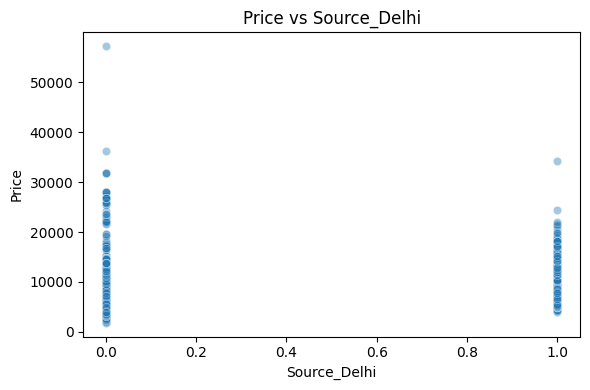

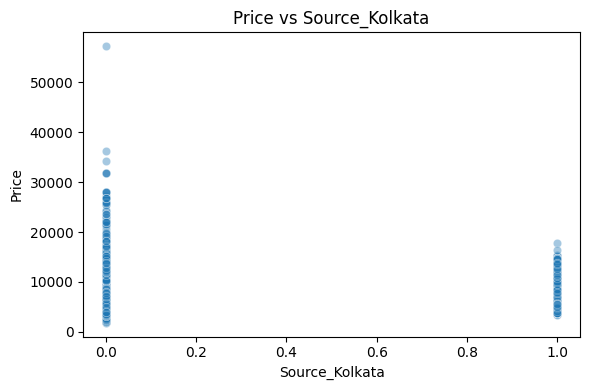

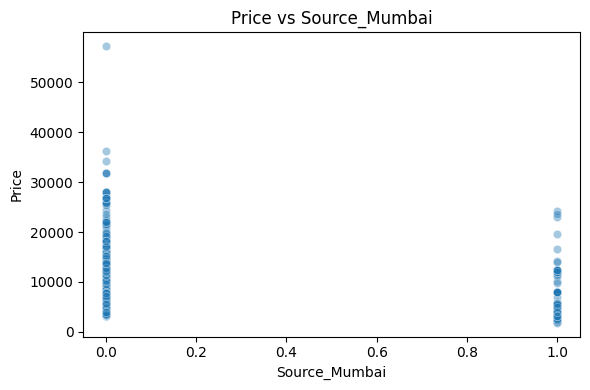

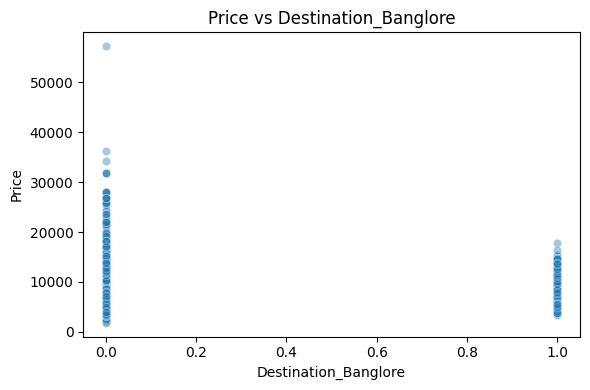

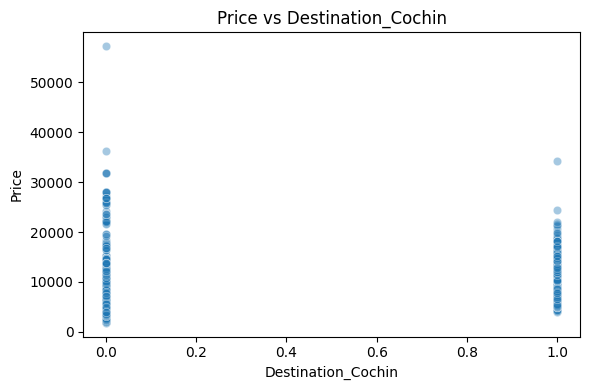

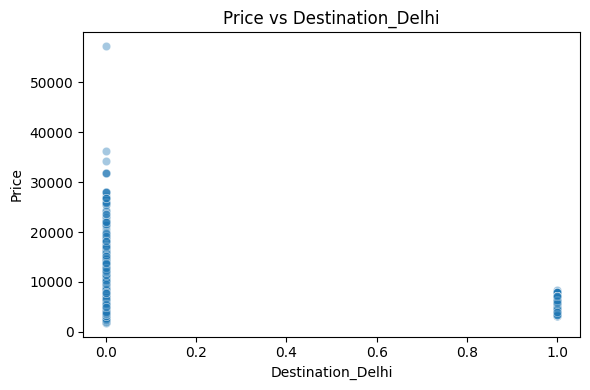

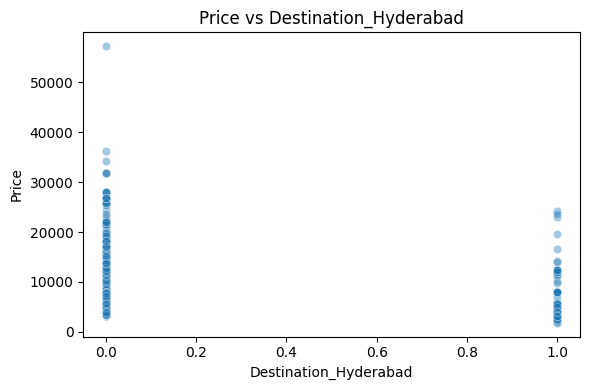

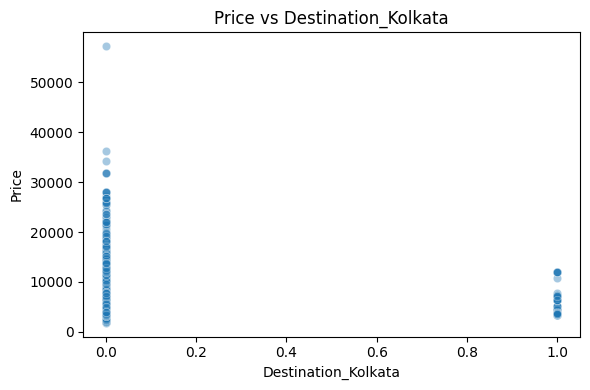

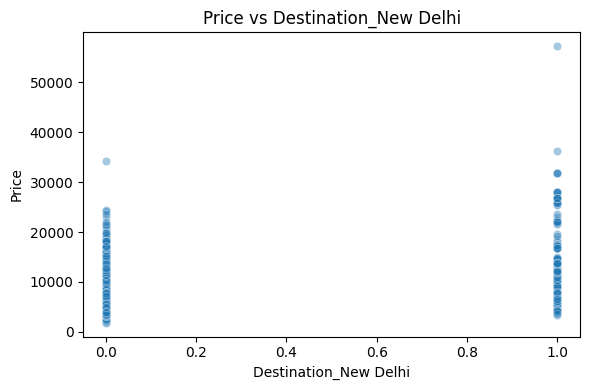

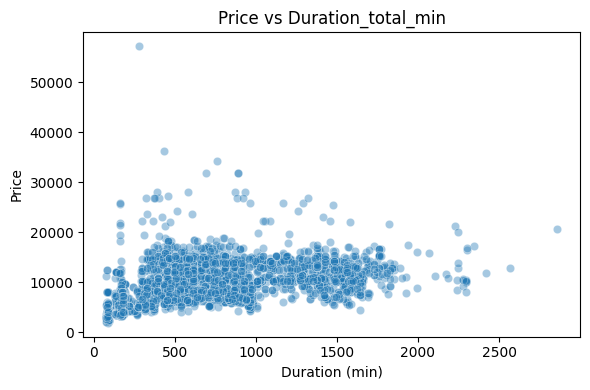

In [148]:
if target_col:
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]

    for col in num_cols:
        if col == "Duration_total_min":
            x_label = "Duration (min)"
        else:
            x_label = col
        plt.figure(figsize=(6, 4))
        sns.scatterplot(
            data=df.sample(min(len(df), 3000), random_state=42),
            x=col,
            y=target_col,
            alpha=0.4,
        )
        plt.xlabel(x_label)
        plt.title(f"{target_col} vs {col}")
        plt.tight_layout()
        plt.show()

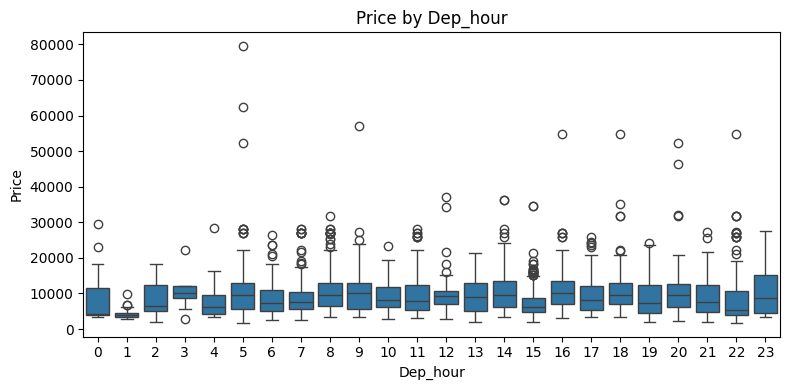

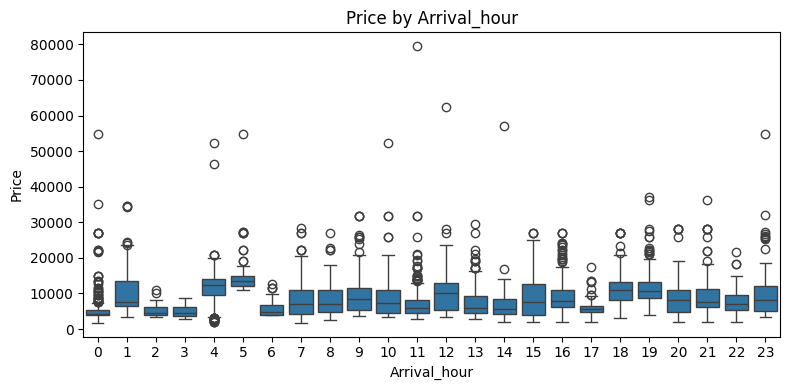

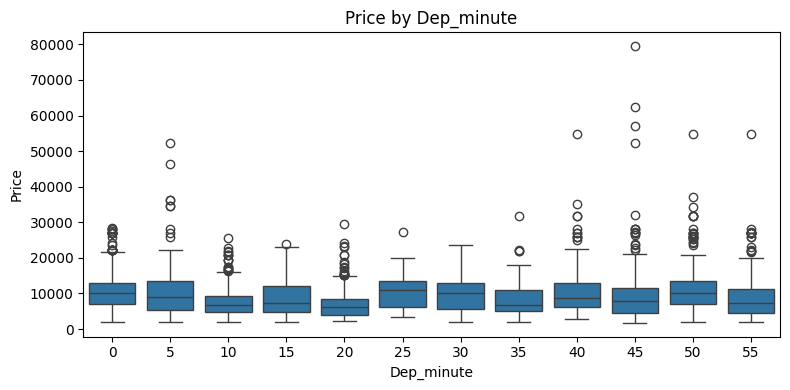

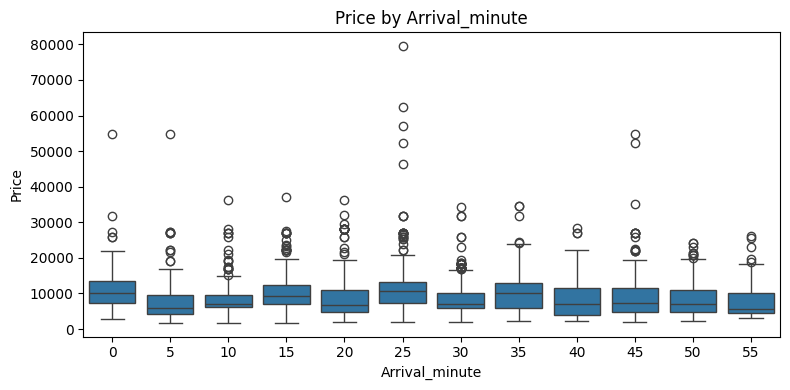

In [149]:
if target_col:
    time_cols = [
        "Dep_hour",
        "Arrival_hour",
        "Dep_minute",
        "Arrival_minute",
    ]
    time_cols = [c for c in time_cols if c in df.columns]

    for col in time_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=col, y=target_col)
        plt.title(f"{target_col} by {col}")
        plt.tight_layout()
        plt.show()

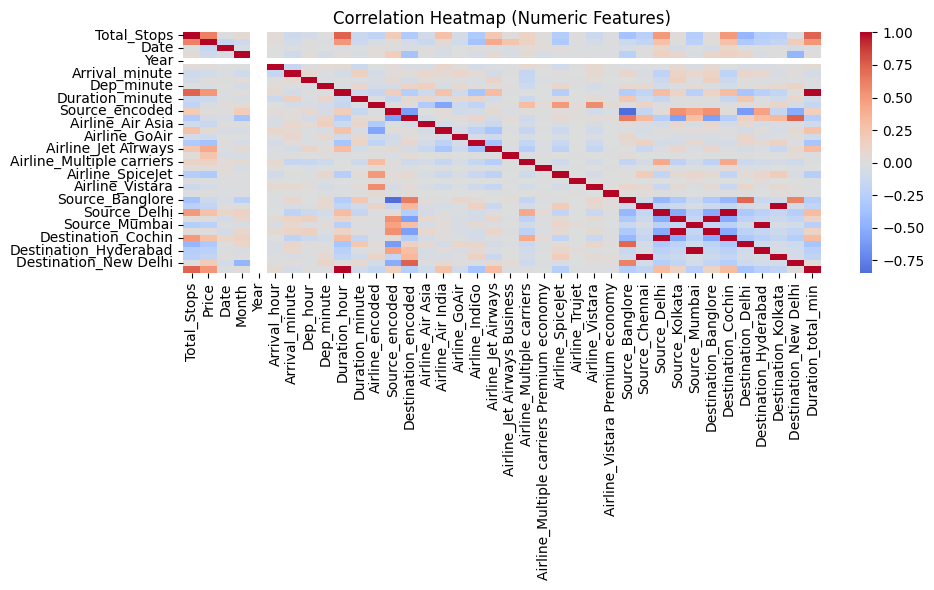

In [150]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 6))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

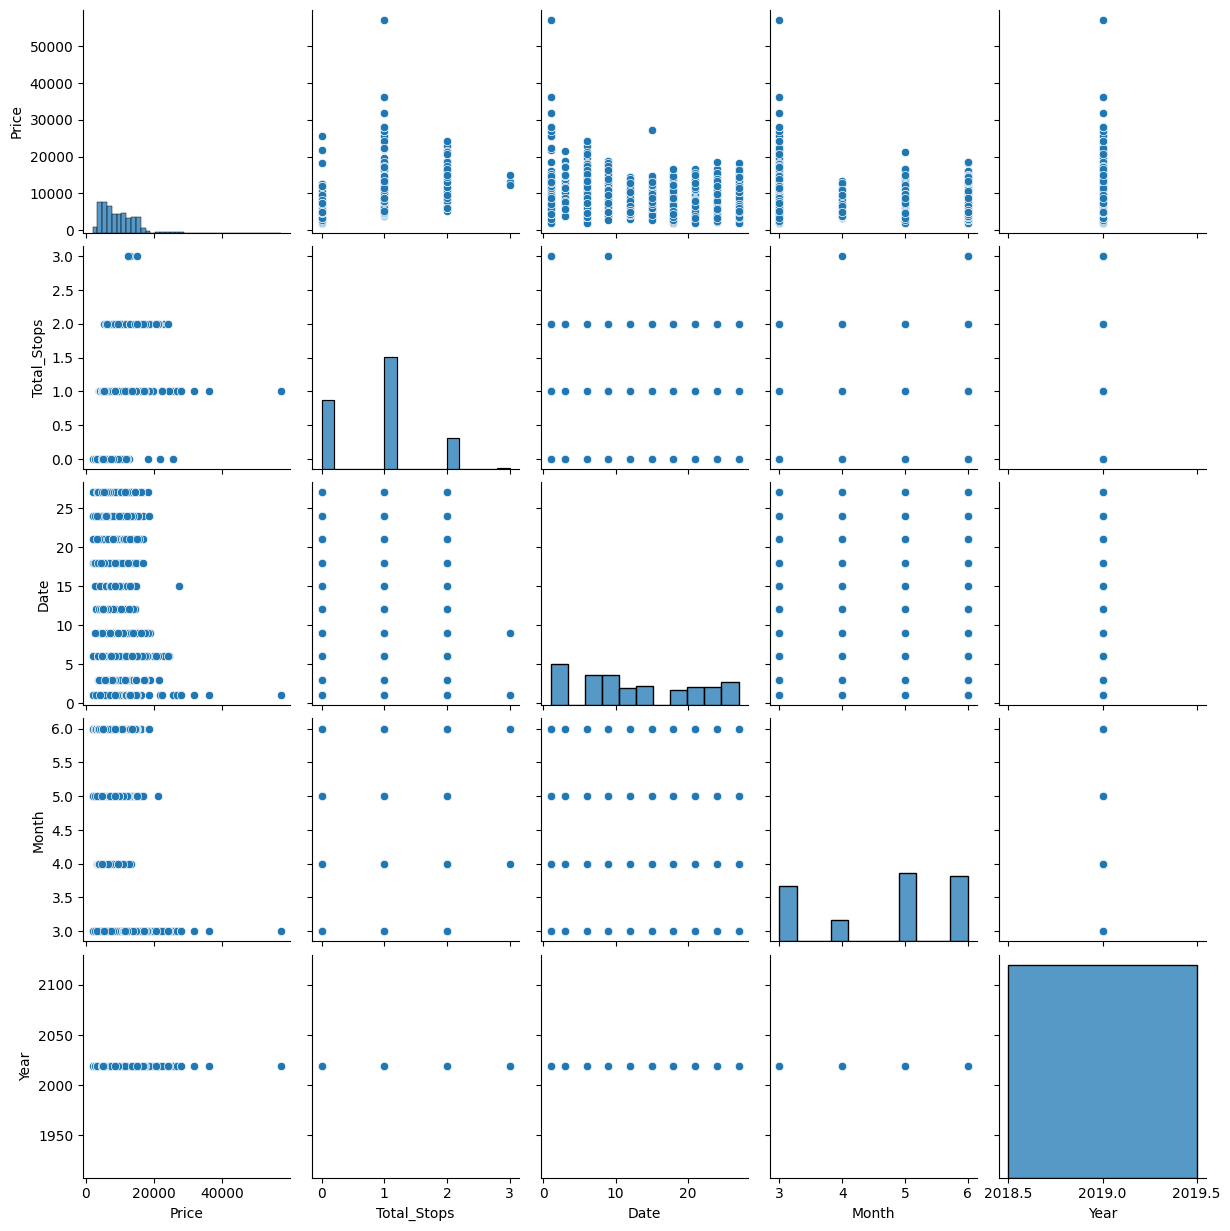

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_

In [ ]:
pair_cols = num_df.columns.tolist()
if target_col and target_col in pair_cols:
    keep = [target_col] + [c for c in pair_cols if c != target_col][:4]
    sample_df = num_df[keep].sample(min(len(num_df), 1000), random_state=42)
    sns.pairplot(sample_df)
    plt.show()